In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import matplotlib
matplotlib.rcParams["figure.figsize"] = (8,2)
df = pd.read_csv("../customer_churn.csv")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [49]:
print(df["Count"].value_counts())
print(df["Country"].value_counts())
print(df["State"].value_counts())

Count
1    7043
Name: count, dtype: int64
Country
United States    7043
Name: count, dtype: int64
State
California    7043
Name: count, dtype: int64


In [50]:
df1 = df.drop(['Churn Reason', 'CustomerID', 'Lat Long', 'Latitude', 'Longitude', 'Count', 'Country', 'State', 'Churn Label', 'Churn Score', 'CLTV', 'City', 'Zip Code'], axis = 'columns')

In [51]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             7043 non-null   object 
 1   Senior Citizen     7043 non-null   object 
 2   Partner            7043 non-null   object 
 3   Dependents         7043 non-null   object 
 4   Tenure Months      7043 non-null   int64  
 5   Phone Service      7043 non-null   object 
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Streaming TV       7043 non-null   object 
 13  Streaming Movies   7043 non-null   object 
 14  Contract           7043 non-null   object 
 15  Paperless Billing  7043 non-null   object 
 16  Payment Method     7043 

In [52]:
df1.describe()

,Tenure Months,Monthly Charges,Churn Value
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,0.265370
std,24.559481,30.090047,0.441561
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,0.000000
50%,29.000000,70.350000,0.000000
75%,55.000000,89.850000,1.000000
max,72.000000,118.750000,1.000000


In [53]:
df1.isnull().sum()

Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dtype: int64

In [54]:
df1.duplicated().sum()

np.int64(22)

In [55]:
duplicates = df1[df1.duplicated()]
duplicates

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
242,Male,No,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.7,1
351,Male,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,1
456,Male,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.9,1
859,Female,Yes,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.6,1
1080,Male,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.2,1
1173,Female,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.90,20.9,1
1522,Female,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,70.15,70.15,1
1656,Female,No,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.10,70.1,1
1722,Male,No,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,No,Electronic check,45.30,45.3,1
1751,Male,No,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.10,20.1,1


In [56]:
df2 = df1.drop_duplicates()
df2.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,1


In [57]:
df2.duplicated().sum()

np.int64(0)

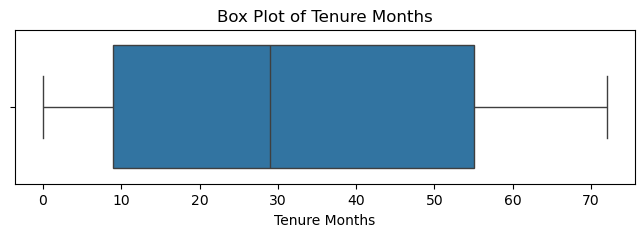

In [58]:
# Inspecting for outliers
sns.boxplot(x=df2['Tenure Months'])

plt.title("Box Plot of Tenure Months")
plt.xlabel("Tenure Months")

plt.show()

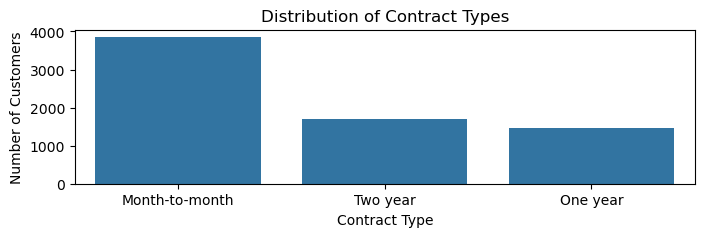

In [59]:
sns.countplot(x='Contract', data=df2)

plt.title("Distribution of Contract Types")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [60]:
binary_cols = [
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Paperless Billing'
]

for col in binary_cols:
    print(col, df2[col].unique())

for col in binary_cols:
    df2.loc[:, col] = df2[col].map({
        'Yes':1,
        'No':0
    })

df2.loc[:, 'Gender'] = df2['Gender'].map({
    'Male':1,
    'Female':0
})

Senior Citizen ['No' 'Yes']
Partner ['No' 'Yes']
Dependents ['No' 'Yes']
Phone Service ['Yes' 'No']
Paperless Billing ['Yes' 'No']


In [61]:
for col in binary_cols:
    print(col, df2[col].unique())

Senior Citizen [0 1]
Partner [0 1]
Dependents [0 1]
Phone Service [1 0]
Paperless Billing [1 0]


In [62]:
for col in [
    'Gender',
    'Senior Citizen',
    'Partner',
    'Dependents',
    'Phone Service',
    'Paperless Billing'
]:
    df2[col] = df2[col].astype(int)
df2.dtypes

C:\Users\mitta\AppData\Local\Temp\ipykernel_23632\4136102211.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[col] = df2[col].astype(int)
C:\Users\mitta\AppData\Local\Temp\ipykernel_23632\4136102211.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[col] = df2[col].astype(int)
C:\Users\mitta\AppData\Local\Temp\ipykernel_23632\4136102211.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See th

Gender                 int64
Senior Citizen         int64
Partner                int64
Dependents             int64
Tenure Months          int64
Phone Service          int64
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing      int64
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Value            int64
dtype: object

In [63]:
multi_cols = [
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Online Backup',
    'Device Protection',
    'Tech Support',
    'Streaming TV',
    'Streaming Movies',
    'Contract',
    'Payment Method'
]

# drop_first = True avoids the dummy variable trap
df3 = pd.get_dummies(df2, columns=multi_cols, drop_first=True)
df3.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,...,Tech Support_Yes,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
1,0,0,0,1,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False
2,0,0,0,1,8,1,1,99.65,820.5,1,...,False,False,True,False,True,False,False,False,True,False
3,0,0,1,1,28,1,1,104.80,3046.05,1,...,True,False,True,False,True,False,False,False,True,False
4,1,0,0,1,49,1,1,103.70,5036.3,1,...,False,False,True,False,True,False,False,False,False,False


In [64]:
df3['Total Charges'].dtype

dtype('O')

In [65]:
(df3["Total Charges"].str.strip() == '').sum()

np.int64(11)

In [66]:
df3 = df3[df3["Total Charges"].str.strip() != ""]
(df3["Total Charges"].str.strip() == '').sum()

np.int64(0)

In [67]:
df3['Total Charges'] = pd.to_numeric(
    df3['Total Charges']
)
df3['Total Charges'].dtype

dtype('float64')

In [68]:
df3.dtypes

Gender                                      int64
Senior Citizen                              int64
Partner                                     int64
Dependents                                  int64
Tenure Months                               int64
Phone Service                               int64
Paperless Billing                           int64
Monthly Charges                           float64
Total Charges                             float64
Churn Value                                 int64
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No internet service        bool
Device Protection_Yes                        bool


In [69]:
#Feature Engineering
df3.loc[:,'Average Monthly Spending'] = (
    df3['Total Charges'] /
    df3['Tenure Months'].replace(0, np.nan)
)
# If joined just now, then avg will be current charge itself
df3.loc[:,'Average Monthly Spending'] = (
    df3['Average Monthly Spending']
    .fillna(df3['Monthly Charges'])
)
df3['Average Monthly Spending']

0        54.075000
1        75.825000
2       102.562500
3       108.787500
4       102.781633
           ...    
7038     19.713889
7039     82.937500
7040    102.262500
7041     31.495455
7042    103.704545
Name: Average Monthly Spending, Length: 7010, dtype: float64

In [70]:
df3['Long-term Customer'] = (
    df3['Tenure Months'] > 24
).astype(int)
df3['Long-term Customer']

0       0
1       0
2       0
3       1
4       1
       ..
7038    1
7039    0
7040    1
7041    0
7042    1
Name: Long-term Customer, Length: 7010, dtype: int64

In [71]:
service_cols = [
    'Online Security_Yes',
    'Online Backup_Yes',
    'Device Protection_Yes',
    'Tech Support_Yes',
    'Streaming TV_Yes',
    'Streaming Movies_Yes'
]

df3['Number of Services'] = df3[service_cols].sum(axis=1)
df3['Number of Services']

0       2
1       0
2       3
3       4
4       4
       ..
7038    0
7039    5
7040    4
7041    1
7042    5
Name: Number of Services, Length: 7010, dtype: int64

In [72]:
df3.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Paperless Billing,Monthly Charges,Total Charges,Churn Value,...,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check,Average Monthly Spending,Long-term Customer,Number of Services
0,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,True,54.075000,0,2
1,0,0,0,1,2,1,1,70.70,151.65,1,...,False,False,False,False,False,True,False,75.825000,0,0
2,0,0,0,1,8,1,1,99.65,820.50,1,...,False,True,False,False,False,True,False,102.562500,0,3
3,0,0,1,1,28,1,1,104.80,3046.05,1,...,False,True,False,False,False,True,False,108.787500,1,4
4,1,0,0,1,49,1,1,103.70,5036.30,1,...,False,True,False,False,False,False,False,102.781633,1,4


In [73]:
# Model Building
X = df3.drop('Churn Value', axis=1)
y = df3['Churn Value']
X.dtypes

Gender                                      int64
Senior Citizen                              int64
Partner                                     int64
Dependents                                  int64
Tenure Months                               int64
Phone Service                               int64
Paperless Billing                           int64
Monthly Charges                           float64
Total Charges                             float64
Multiple Lines_No phone service              bool
Multiple Lines_Yes                           bool
Internet Service_Fiber optic                 bool
Internet Service_No                          bool
Online Security_No internet service          bool
Online Security_Yes                          bool
Online Backup_No internet service            bool
Online Backup_Yes                            bool
Device Protection_No internet service        bool
Device Protection_Yes                        bool
Tech Support_No internet service             bool


In [74]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y #Scikit-learn first looks at the target variable (y) and says: "The original dataset has 73.9% No and 26.1% Yes. I'll preserve that ratio in both the training and testing sets."
)

In [75]:
# Feature scaling: bringing numerical features to a similar range without changing their relative importance.
# If any column has much larger values, some algorithms will treat it as much more important, even if it's not.
# That's why StandardScaler. It transforms every feature so that Mean = 0 & Standard Deviation = 1 i.e. feature is centered around 0.
# Formula: z = (x-Mean)/SD
# Scale before Logistic Regression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
) #scaler computes the mean and standard deviation from the training data and uses them to scale it.
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)#scaled using the same mean and standard deviation learned from the training set because of using transform() and not fit_transform()

In [76]:
#Importing models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [77]:
#Model training
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42) # Try up to 1000 iterations to find the best coefficients. [default = 100]
#It doesn't mean it will always perform 1000 iterations. If it converges after 85 iterations, it stops there. So 1000 is simply an upper limit.
lr.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [78]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [79]:
rf = RandomForestClassifier(
    random_state=42
)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [80]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [81]:
# Predictions
y_pred_lr = lr.predict(X_test_scaled)

In [82]:
y_pred_dt = dt.predict(X_test)

In [83]:
y_pred_rf = rf.predict(X_test)

In [84]:
y_pred_xgb = xgb.predict(X_test)

In [85]:
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score #shows how the model performs across all possible thresholds.
)

results = []

models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb
}

for model_name, y_pred in models.items():
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df.sort_values(by="ROC-AUC", ascending=False)
# AUC - Area Under the ROC Curve, the value always lies between 0 and 1.

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.808131,0.663462,0.557951,0.606149,0.728054
3,XGBoost,0.781740,0.604502,0.506739,0.551320,0.693718
2,Random Forest,0.788160,0.633094,0.474394,0.542373,0.687730
1,Decision Tree,0.723966,0.478947,0.490566,0.484687,0.649260


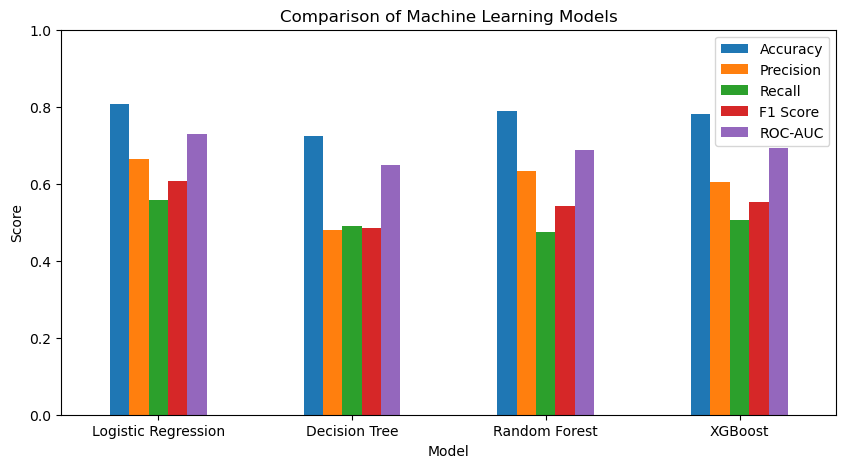

In [86]:
results_df.set_index('Model').plot( #Model is no longer treated as a data column. This is important because plot() uses the index for the x-axis.
    kind='bar',
    figsize=(10,5)
)

plt.ylabel("Score")
plt.title("Comparison of Machine Learning Models")
plt.xticks(rotation=0) #By default, long labels overlap. Rotating makes them more readable.
plt.ylim(0, 1) #Sets the y-axis range.
plt.show()

In [87]:
# Choosing Logistic Regression

In [88]:
# Global Feature Importance: Which features influence the model the most?
importance_lr = pd.DataFrame({
    "Feature": X_train.columns, #column name same as scaled
    "Coefficient": lr.coef_[0] #coefficient itself tells us how strongly a feature affects the prediction
})

importance_lr["Absolute"] = importance_lr["Coefficient"].abs()

importance_lr = importance_lr.sort_values(
    by="Absolute",
    ascending=False
)

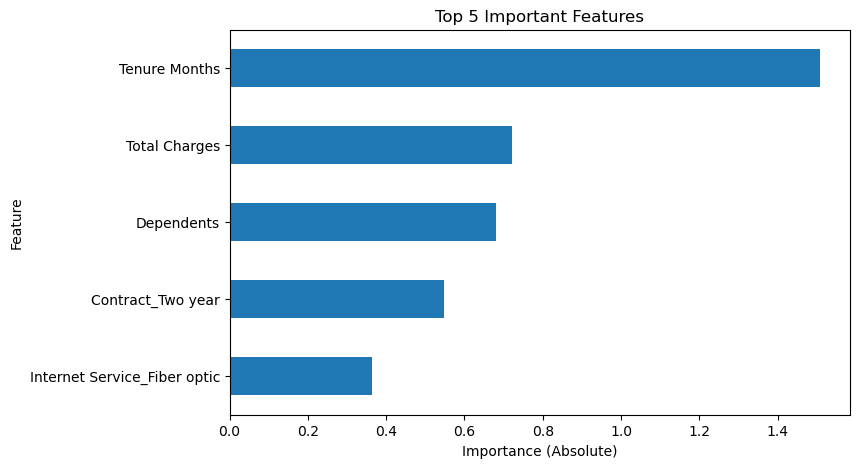

In [89]:
importance_lr.head(5).plot(
    x="Feature",
    y="Absolute",
    kind="barh",
    legend=False,
    figsize=(8,5)
)

plt.title("Top 5 Important Features")
plt.xlabel("Importance (Absolute)")
plt.gca().invert_yaxis()
plt.show()

Background dataset has 5608 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5608 when initializing the masker.


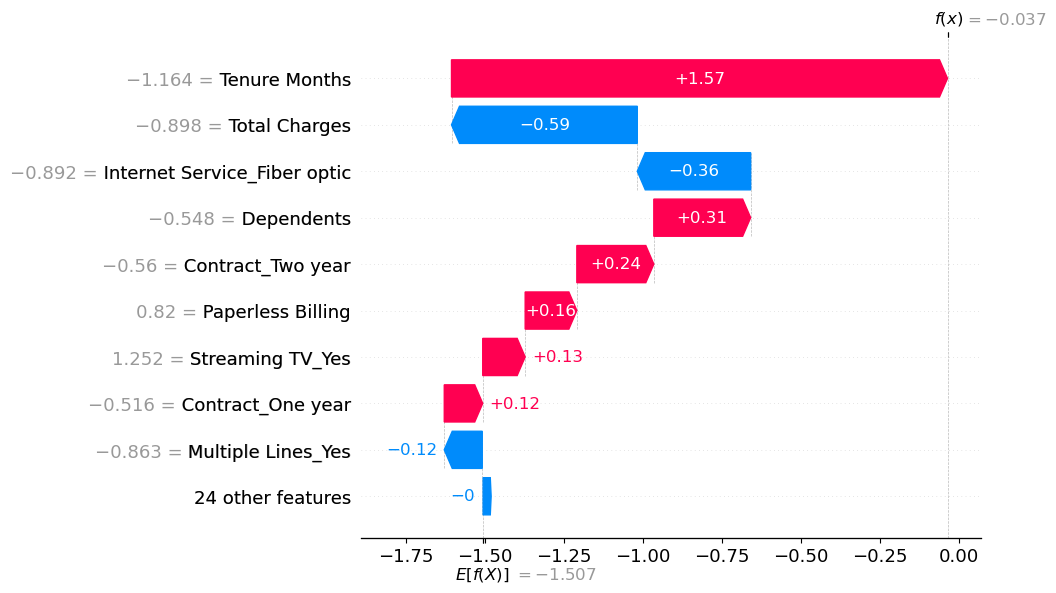

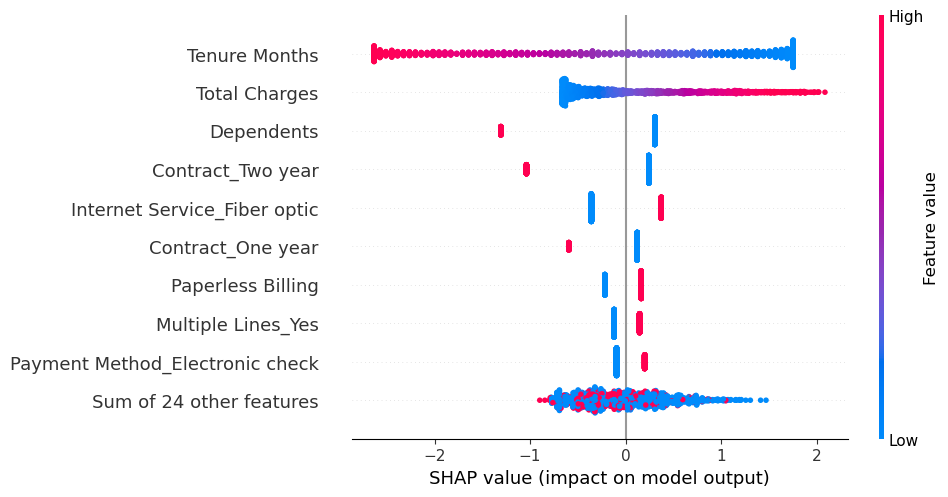

Risk of Churn : 49.08%


In [90]:
# (SHAP) - SHapley Additive exPlanations: how much each feature pushed the prediction toward churn or toward not churning.
import shap
explainer = shap.LinearExplainer(lr, X_train_scaled) #SHAP's explanation engine
shap_values = explainer(X_test_scaled) # Explain the entire test set
customer = X_test_scaled[5:6] # Select one customer
customer_data = customer.iloc[0]
probability = lr.predict_proba(customer)[0][1]

# Waterfall plot (local explanation)
shap.plots.waterfall(shap_values[5])

# Summary plot (global explanation)
shap.plots.beeswarm(shap_values)

print(f"Risk of Churn : {probability:.2%}")

In [91]:
explanation = pd.DataFrame({
    "Feature": customer.columns,
    "Contribution": explainer.shap_values(customer)[0]
})

explanation = explanation.sort_values(
    by="Contribution",
    key=abs,
    ascending=False
)
top_features = explanation.head(15)
top_features

,Feature,Contribution
4,Tenure Months,1.569813
8,Total Charges,-0.588022
11,Internet Service_Fiber optic,-0.358754
3,Dependents,0.306477
26,Contract_Two year,0.243593
6,Paperless Billing,0.163556
22,Streaming TV_Yes,0.134352
25,Contract_One year,0.121715
10,Multiple Lines_Yes,-0.120288
24,Streaming Movies_Yes,0.113393


In [98]:
print("\nBusiness Interpretation")
print("-"*30)

printed = set()

for _, row in top_features.iterrows():

    feature = row["Feature"]

    # ---------------- Tenure ----------------
    if feature == "Tenure Months" and "Tenure" not in printed:
        tenure = customer_data["Tenure Months"]
        if tenure < 12:
            print(f"• Customer has been with the company for only {tenure} months.")
        elif tenure < 24:
            print(f"• Customer has moderate tenure ({tenure} months).")
        else:
            print(f"• Customer has been with the company for {tenure} months.")

        printed.add("Tenure")

    # ---------------- Total Charges ----------------
    elif feature == "Total Charges" and "Total Charges" not in printed:

        total = customer_data["Total Charges"]

        print(f"• Total charges paid by the customer are ₹{total:.2f}.")

        printed.add("Total Charges")

    # ---------------- Dependents ----------------
    elif feature == "Dependents" and "Dependents" not in printed:

        if customer_data["Dependents"] == 1:
            print("• Customer has dependents.")
        else:
            print("• Customer does not have dependents.")

        printed.add("Dependents")

    # ---------------- Partner ----------------
    elif feature == "Partner" and "Partner" not in printed:

        if customer_data["Partner"] == 1:
            print("• Customer has a partner.")
        else:
            print("• Customer does not have a partner.")

        printed.add("Partner")

    # ---------------- Paperless Billing ----------------
    elif feature == "Paperless Billing" and "Paperless Billing" not in printed:

        if customer_data["Paperless Billing"] == 1:
            print("• Customer uses paperless billing.")
        else:
            print("• Customer does not use paperless billing.")

        printed.add("Paperless Billing")

    # ---------------- Multiple Lines ----------------
    elif feature == "Multiple Lines_Yes" and "Multiple Lines" not in printed:

        if customer_data["Multiple Lines_Yes"] == 1:
            print("• Customer has multiple phone lines.")
        else:
            print("• Customer has a single phone line.")

        printed.add("Multiple Lines")

    # ---------------- Online Backup ----------------
    elif feature == "Online Backup_Yes" and "Online Backup" not in printed:

        if customer_data["Online Backup_Yes"] == 1:
            print("• Customer subscribes to online backup.")
        else:
            print("• Customer does not subscribe to online backup.")

        printed.add("Online Backup")

    # ---------------- Streaming TV ----------------
    elif feature == "Streaming TV_Yes" and "Streaming TV" not in printed:

        if customer_data["Streaming TV_Yes"] == 1:
            print("• Customer subscribes to Streaming TV.")
        else:
            print("• Customer does not subscribe to Streaming TV.")

        printed.add("Streaming TV")

    # ---------------- Streaming Movies ----------------
    elif feature == "Streaming Movies_Yes" and "Streaming Movies" not in printed:

        if customer_data["Streaming Movies_Yes"] == 1:
            print("• Customer subscribes to Streaming Movies.")
        else:
            print("• Customer does not subscribe to Streaming Movies.")

        printed.add("Streaming Movies")

    # ---------------- Tech Support ----------------
    elif feature == "Tech Support_Yes" and "Tech Support" not in printed:

        if customer_data["Tech Support_Yes"] == 1:
            print("• Customer has Tech Support.")
        else:
            print("• Customer does not have Tech Support.")

        printed.add("Tech Support")

    # ---------------- Long-term Customer ----------------
    elif feature == "Long-term Customer" and "Long-term Customer" not in printed:

        if customer_data["Long-term Customer"] == 1:
            print("• Customer is a long-term customer.")
        else:
            print("• Customer is a relatively new customer.")

        printed.add("Long-term Customer")

    # ---------------- Internet ----------------
    elif feature.startswith("Internet Service_Fiber Optic") and "Internet" not in printed:
        internet = customer_data["Internet Service"]
        print(f"• Customer uses {internet} internet.")

        printed.add("Internet")

    # ---------------- Contract ----------------
    elif feature.startswith("Contract") and "Contract" not in printed:
        contract = customer_data["Contract_Two year"]
        if (contract == 1):
            c = "two year"
        else:
            c = "one year"
        print(f"• Customer is on a {c.lower()} contract.")

        printed.add("Contract")

print("• These characteristics were among the most influential factors considered by the model while estimating churn risk.")


Business Interpretation
------------------------------
• Customer has been with the company for only -1.1642607287850442 months.
• Total charges paid by the customer are ₹-0.90.
• Customer does not have dependents.
• Customer is on a one year contract.
• Customer does not use paperless billing.
• Customer does not subscribe to Streaming TV.
• Customer has a single phone line.
• Customer does not subscribe to Streaming Movies.
• Customer does not have a partner.
• Customer does not subscribe to online backup.
• Customer is a relatively new customer.
• Customer does not have Tech Support.
• These characteristics were among the most influential factors considered by the model while estimating churn risk.


In [ ]:
import pickle
with open('churn_model.pickle', 'wb') as f:
    pickle.dump(lr,f);

In [ ]:
import json
columns = {
    'data_columns': [col.lower() for col in X.columns]
}

with open("columns.json","w") as f:
    f.write(json.dumps(columns))

In [99]:
X.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Paperless Billing', 'Monthly Charges',
       'Total Charges', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check',
       'Average Monthly Spending', 'Long-term Customer', 'Number of Services'],
      dtype='object')